In [ ]:
import os

# Pastas Principais
base_dir = 'wikiart_dataset'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Ordenar Classes
classes_desordenadas = os.listdir(train_dir)
classes = sorted(classes_desordenadas)

print("Contagem de Imagens por Pasta e Classe:\n")
print(f"{'Classe':<23} | {'Treino':<8} | {'Validação':<10} | {'Teste':<8}")
print("-" * 56)

total_treino = 0
total_validacao = 0
total_teste = 0

for c in classes:
    
    pasta_treino_classe = os.path.join(train_dir, c)
    pasta_val_classe = os.path.join(validation_dir, c)
    pasta_teste_classe = os.path.join(test_dir, c)
    
    train_count = len(os.listdir(pasta_treino_classe))
    val_count = len(os.listdir(pasta_val_classe))
    test_count = len(os.listdir(pasta_teste_classe))
    
    total_treino = total_treino + train_count
    total_validacao = total_validacao + val_count
    total_teste = total_teste + test_count
    
    print(f"{c:<23} | {train_count:<8} | {val_count:<10} | {test_count:<8}")

print("-" * 56)

print("\nTotal Treino:    ", total_treino)
print("Total Validação: ", total_validacao)
print("Total Teste:     ", total_teste)

Contagem de Imagens por Pasta e Classe:

Classe                  | Treino   | Validação  | Teste   
--------------------------------------------------------
Abstract Expressionism  | 1500     | 500        | 500     
Art Nouveau (Modern)    | 1500     | 500        | 500     
Baroque                 | 1500     | 500        | 500     
Cubism                  | 1500     | 500        | 500     
Expressionism           | 1500     | 500        | 500     
Impressionism           | 1500     | 500        | 500     
Neoclassicism           | 1500     | 500        | 500     
Northern Renaissance    | 1500     | 500        | 500     
Pop Art                 | 1500     | 500        | 500     
Post-Impressionism      | 1500     | 500        | 500     
Realism                 | 1500     | 500        | 500     
Rococo                  | 1500     | 500        | 500     
Romanticism             | 1500     | 500        | 500     
Surrealism              | 1500     | 500        | 500     
Symbolism        

In [2]:
from keras.utils import image_dataset_from_directory

IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

validation_dataset = image_dataset_from_directory(
    validation_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

I0000 00:00:1780012336.145883  145239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780012336.226099  145239 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780012337.730450  145239 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 22500 files belonging to 15 classes.


I0000 00:00:1780012342.309484  145239 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9513 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 7500 files belonging to 15 classes.
Found 7500 files belonging to 15 classes.


In [3]:
for data_batch, labels_batch in train_dataset:
    print("Verificação do Formato dos Dados:")
    print(f"Batch de Imagens:   {data_batch.shape} -> [Tamanho do Batch, Altura, Largura, Canais RGB]")
    print(f"Batch de Etiquetas: {labels_batch.shape} -> [Tamanho do Batch, Número de Classes]")
    break

Verificação do Formato dos Dados:
Batch de Imagens:   (32, 224, 224, 3) -> [Tamanho do Batch, Altura, Largura, Canais RGB]
Batch de Etiquetas: (32, 15) -> [Tamanho do Batch, Número de Classes]


In [4]:
from tensorflow import keras
from keras import layers

data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.2),
])

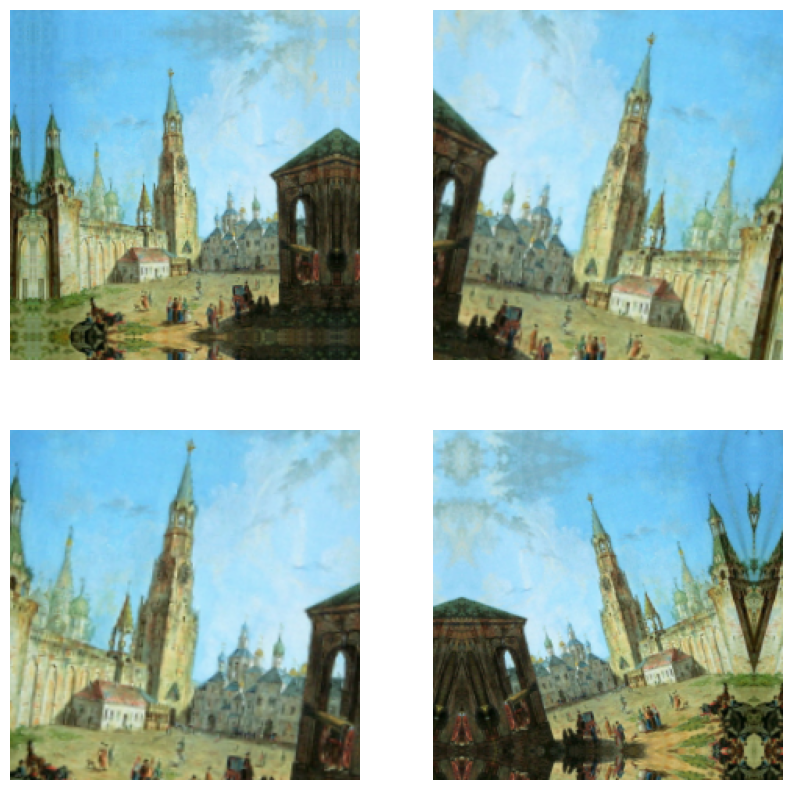

In [5]:
import matplotlib.pyplot as plt


# apresentar 4 primeiras imagens da primeira batch
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(4):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

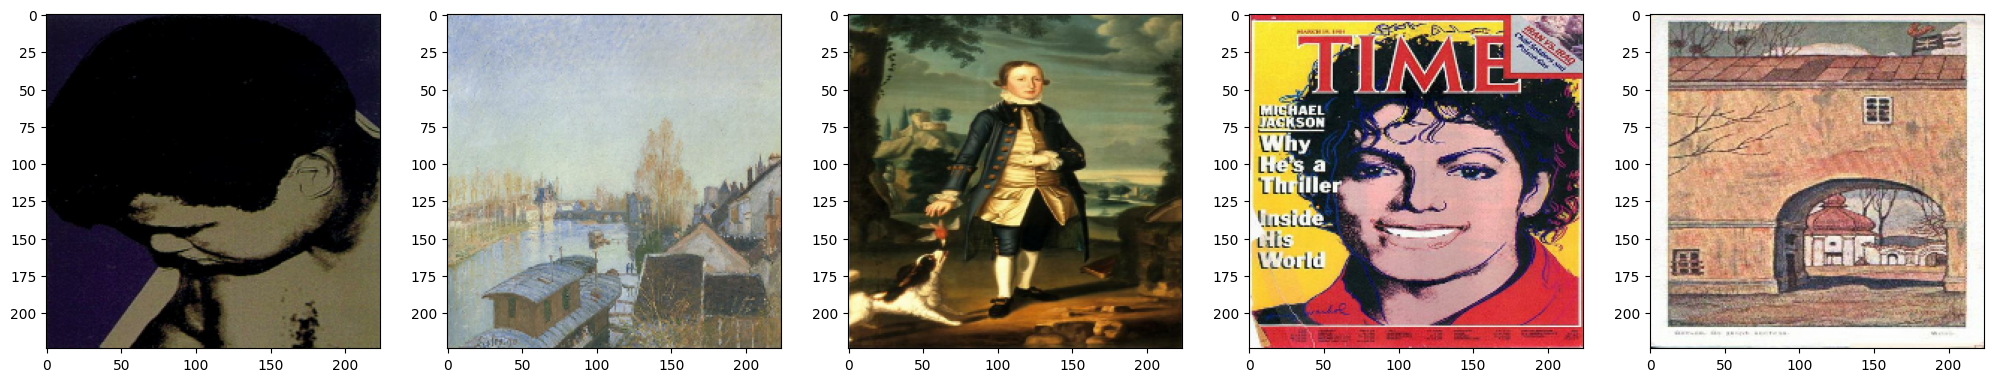

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for data_batch, _ in train_dataset.take(1):
    for i in range(5):

        axes[i].imshow(data_batch[i].numpy().astype("uint8"))
plt.show()

In [7]:
from keras import models
from keras import layers, regularizers

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

l2_regularizer = 0.001

x = layers.Rescaling(1./255)(x)

x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Dropout(0.25)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(25, activation="relu")(x)
outputs = layers.Dense(15, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 50)   │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 50)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 100)  │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 100)    │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 67600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     6,760,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,899,615 (26.32 MB)

 Trainable params: 6,899,615 (26.32 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import tensorflow as tf

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall')])

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("Treino do modelo:")
model_filename = 'models/model_s_with_data_augmentation.keras'

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10),
    keras.callbacks.ModelCheckpoint(
        filepath=model_filename,
        save_best_only=True,
        monitor='val_accuracy')
]

# Training the model
history = model.fit(train_dataset, epochs=200, validation_data=validation_dataset, callbacks=callbacks_list)


Treino do modelo:
Epoch 1/200


I0000 00:00:1780012350.549793  145393 service.cc:153] XLA service 0x442db550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780012350.549838  145393 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1780012350.594794  145393 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780012350.812012  145393 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1780012350.911597  145393 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3183__.54
I0000 00:00:1780012352.934133  145393 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I

253/704 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.0656 - loss: 19.5880 - precision: 0.0587 - recall: 0.0134

W0000 00:00:1780012369.149005  145646 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0668 - loss: 10.3153 - precision: 0.0585 - recall: 0.0064

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.7639 - loss: 0.8633 - precision: 0.8434 - recall: 0.6818 - val_accuracy: 0.2693 - val_loss: 3.4519 - val_precision: 0.3496 - val_recall: 0.1823
Epoch 44/200
257/704 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.7624 - loss: 0.8996 - precision: 0.8380 - recall: 0.6711

W0000 00:00:1780013607.006425  153416 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7646 - loss: 0.8846 - precision: 0.8418 - recall: 0.6777

W0000 00:00:1780013626.659269  153538 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.7654 - loss: 0.8799 - precision: 0.8451 - recall: 0.6806 - val_accuracy: 0.2436 - val_loss: 2.6074 - val_precision: 0.4301 - val_recall: 0.0919


In [11]:
model.save('models/model_s_with_data_augmentation.keras')

In [12]:
print("Avaliação do Modelo no Conjunto de Validção:")

val_loss, val_acc, val_precision, val_recall = model.evaluate(validation_dataset)

print("\nResultados Validação:")
print(f"Loss:        {val_loss:.4f}")
print(f"Accuracy:    {val_acc:.4f}")
print(f"Precision:   {val_precision:.4f}")
print(f"Recall:      {val_recall:.4f}")

Avaliação do Modelo no Conjunto de Validção:
 70/235 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2395 - loss: 2.5548 - precision: 0.4327 - recall: 0.0919

W0000 00:00:1780013627.260384  153586 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2436 - loss: 2.6074 - precision: 0.4301 - recall: 0.0919 

Resultados Validação:
Loss:        2.6074
Accuracy:    0.2436
Precision:   0.4301
Recall:      0.0919


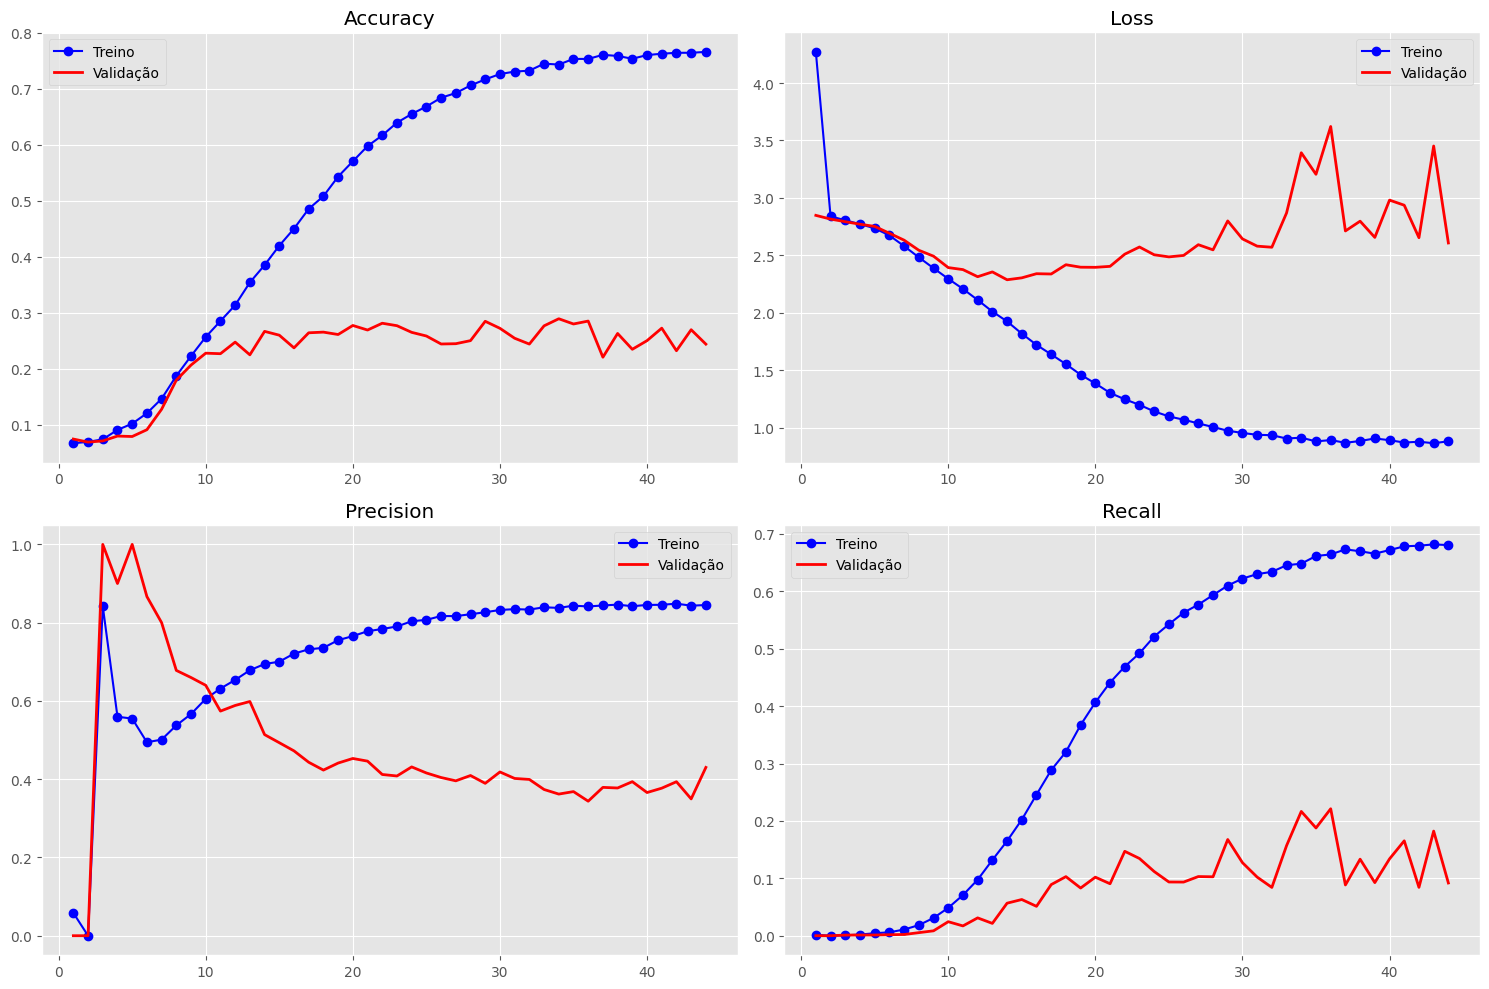

In [13]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

precision = history.history['precision']
val_precision = history.history['val_precision']
recall = history.history['recall']
val_recall = history.history['val_recall']

epochs = range(1, len(acc) + 1)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].plot(epochs, acc, 'bo-', label='Treino')
axs[0, 0].plot(epochs, val_acc, 'r-', linewidth=2, label='Validação')
axs[0, 0].set_title('Accuracy')
axs[0, 0].legend()

axs[0, 1].plot(epochs, loss, 'bo-', label='Treino')
axs[0, 1].plot(epochs, val_loss, 'r-', linewidth=2, label='Validação')
axs[0, 1].set_title('Loss')
axs[0, 1].legend()

axs[1, 0].plot(epochs, precision, 'bo-', label='Treino')
axs[1, 0].plot(epochs, val_precision, 'r-', linewidth=2, label='Validação')
axs[1, 0].set_title('Precision')
axs[1, 0].legend()

axs[1, 1].plot(epochs, recall, 'bo-', label='Treino')
axs[1, 1].plot(epochs, val_recall, 'r-', linewidth=2, label='Validação')
axs[1, 1].set_title('Recall')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Found 7500 files belonging to 15 classes.
 25/235 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

W0000 00:00:1780013630.457063  153651 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


W0000 00:00:1780013633.878049  153736 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


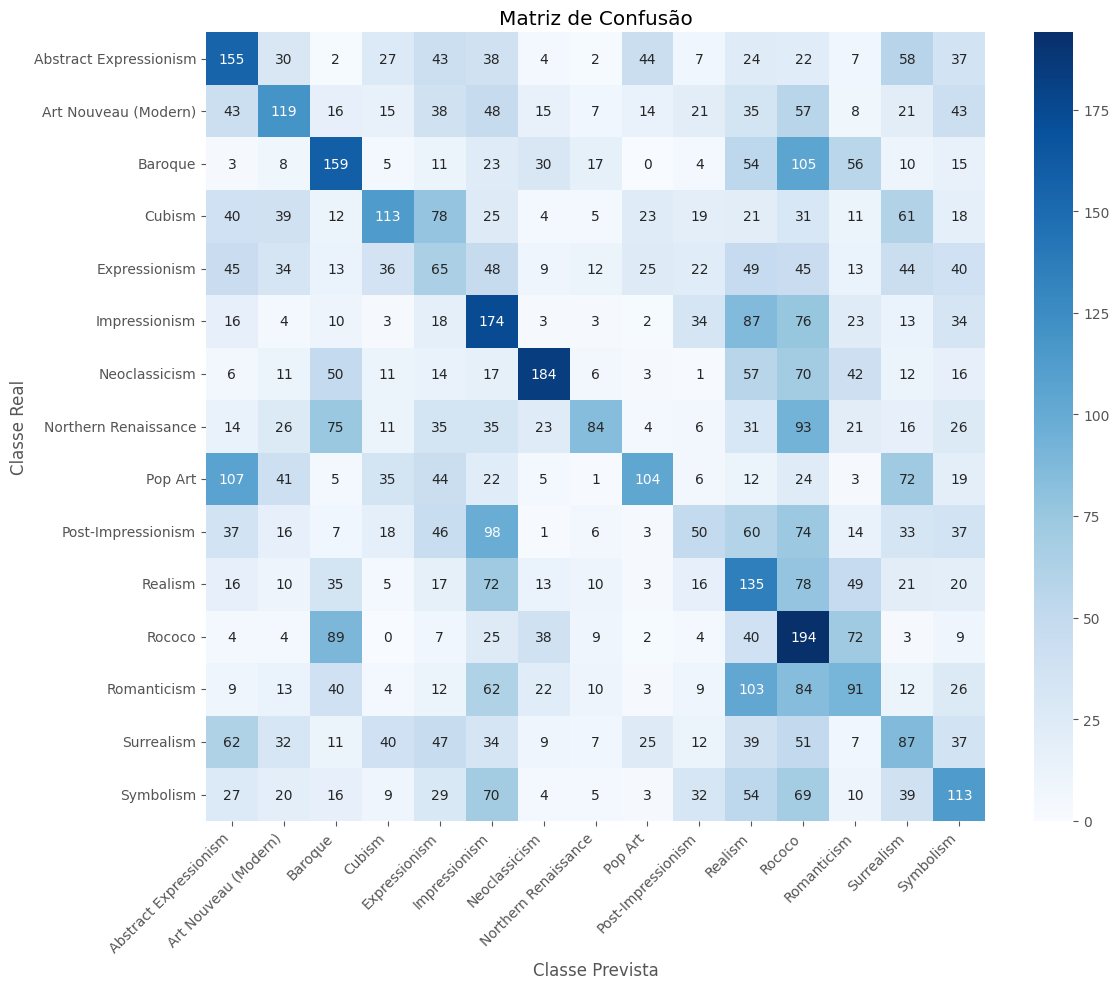

In [14]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Para a Matriz de Confusão, precisamos garantir que as previsões e as etiquetas reais estejam na mesma ordem. Por isso, criamos um dataset de validação sem shuffle.
validation_dataset_unshuffled = image_dataset_from_directory(validation_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False)

previsoes = model.predict(validation_dataset_unshuffled)
previsoes_classes = np.argmax(previsoes, axis=1)

etiquetas_reais = np.concatenate([y for x, y in validation_dataset_unshuffled], axis=0)
etiquetas_reais_classes = np.argmax(etiquetas_reais, axis=1)

cm = confusion_matrix(etiquetas_reais_classes, previsoes_classes)
nomes_classes = validation_dataset_unshuffled.class_names

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)

plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report

print("\nRelatório Detalhado de Classificação:")
# Tabela com Precision, Recall e F1-Score para cada classe
relatorio = classification_report(
    etiquetas_reais_classes, 
    previsoes_classes, 
    target_names=nomes_classes
)

print(relatorio)


Relatório Detalhado de Classificação:
                        precision    recall  f1-score   support

Abstract Expressionism       0.27      0.31      0.29       500
  Art Nouveau (Modern)       0.29      0.24      0.26       500
               Baroque       0.29      0.32      0.31       500
                Cubism       0.34      0.23      0.27       500
         Expressionism       0.13      0.13      0.13       500
         Impressionism       0.22      0.35      0.27       500
         Neoclassicism       0.51      0.37      0.43       500
  Northern Renaissance       0.46      0.17      0.25       500
               Pop Art       0.40      0.21      0.27       500
    Post-Impressionism       0.21      0.10      0.13       500
               Realism       0.17      0.27      0.21       500
                Rococo       0.18      0.39      0.25       500
           Romanticism       0.21      0.18      0.20       500
            Surrealism       0.17      0.17      0.17       500
